# Evaluation Metrics

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 200

In [ ]:
np.random.seed(42)
noise_dev = 0.05
interval = 0.95

## Minimal Incremental Motion

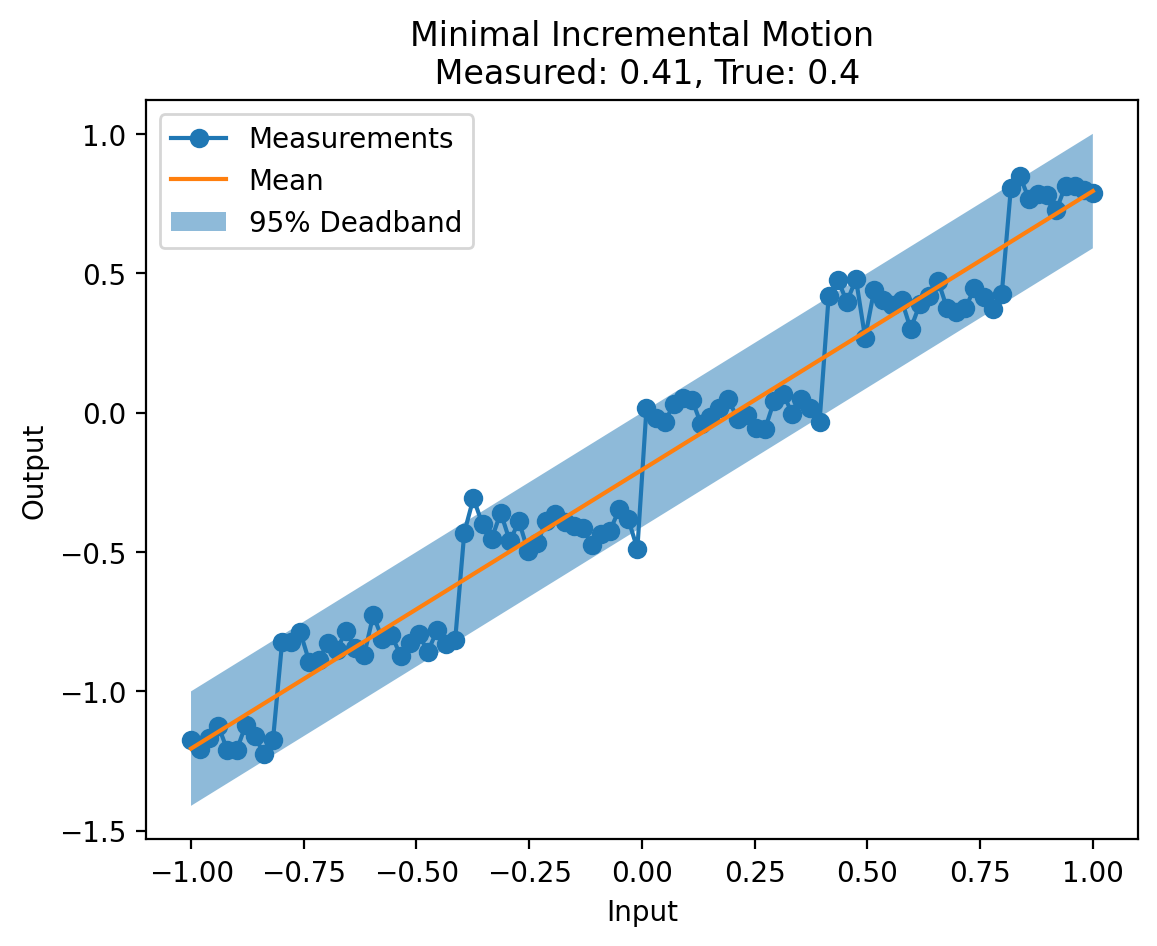

In [ ]:
true_min_increment = 0.4

inputs = np.linspace(-1, 1, 100)
# generate noisy staircase data
outputs = inputs - np.remainder(inputs, true_min_increment) + np.random.normal(0, noise_dev, size=inputs.shape)

mean = np.polynomial.Polynomial([np.mean(outputs-inputs), 1])
residuals = outputs - mean(inputs)
lower, upper = np.quantile(residuals, [(1-interval)/2, 1-(1-interval)/2])
min_increment = upper - lower

plt.plot(inputs, outputs, marker='o', label="Measurements")
plt.plot(inputs, mean(inputs), label="Mean")
plt.fill_between(inputs, mean(inputs) + min_increment/2, mean(inputs) - min_increment/2, alpha=0.5, label=f"{int(interval*100)}% Deadband")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title(f"Minimal Incremental Motion\n Measured: {min_increment:.2f}, True: {true_min_increment}")
plt.legend()
plt.savefig("min_increment.png", bbox_inches="tight")

## Unidirectional Repeatability

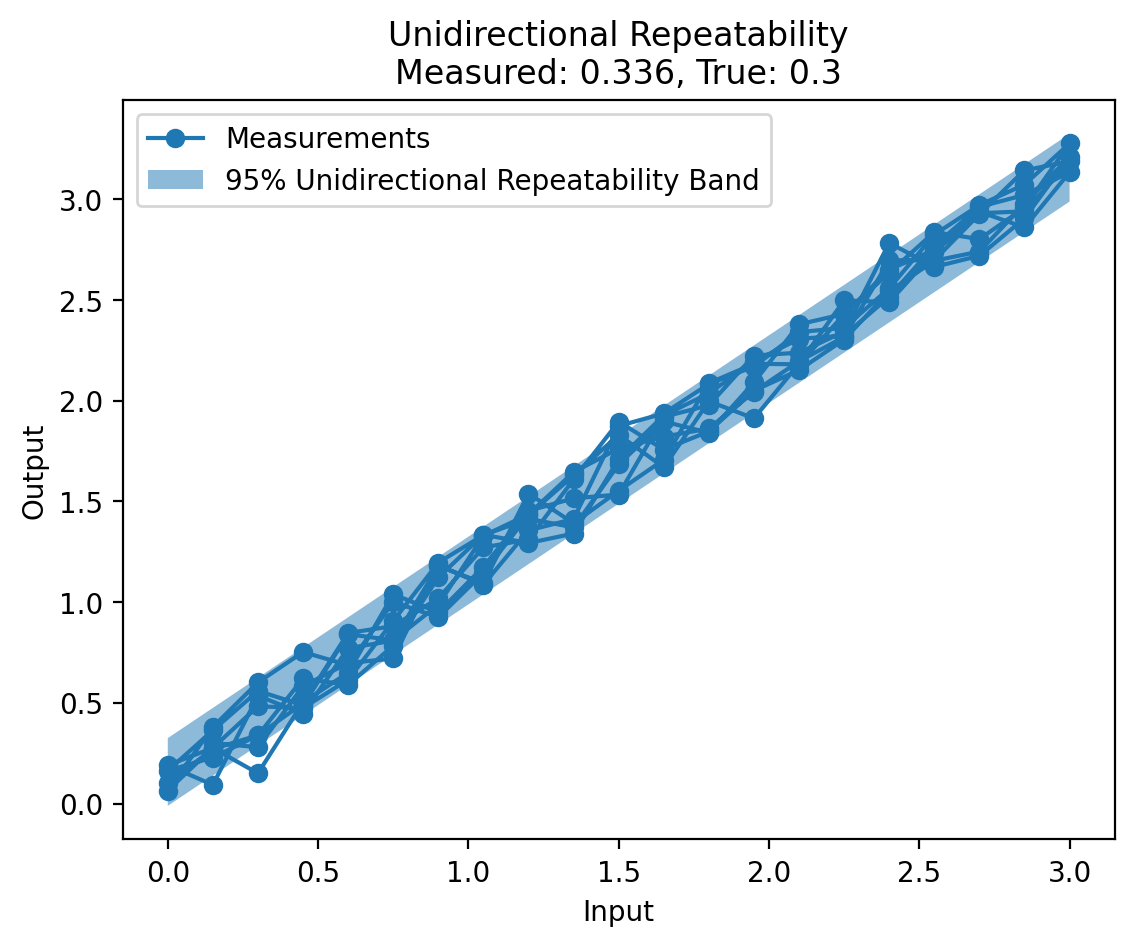

In [ ]:
true_uni_repeatability = 0.3
points_per_segment = 20
amplitude = 3 
num_cycles = 4

inputs_loop = np.tile(np.concatenate([np.arange(points_per_segment), np.arange(points_per_segment, 0, -1)])/points_per_segment*amplitude, num_cycles)
outputs_loop = inputs_loop + np.random.uniform(0, true_uni_repeatability, size=inputs_loop.shape) + np.random.normal(0, noise_dev, size=inputs_loop.shape)

is_forward = np.diff(inputs_loop, prepend=inputs_loop[0]) > 0
is_forward[0] = is_forward[-1]

deviations = np.array([val-np.mean(outputs_loop[(inputs_loop==inp) & (is_forward==fw)]) for inp, val, fw in zip(inputs_loop, outputs_loop, is_forward)])
lower, upper = np.quantile(deviations, [(1-interval)/2, 1-(1-interval)/2])
uni_repeatability = upper - lower

plt.plot(inputs_loop, outputs_loop, marker='o', label="Measurements")

mean = np.polynomial.Polynomial([np.mean(outputs_loop-inputs_loop), 1])
input_range = np.array([np.min(inputs_loop), np.max(inputs_loop)])
plt.fill_between(input_range, mean(input_range) + uni_repeatability/2, mean(input_range) - uni_repeatability/2, alpha=0.5, label=f"{int(interval*100)}% Unidirectional Repeatability Band")
plt.legend()
plt.xlabel("Input")
plt.ylabel("Output")
plt.title(f"Unidirectional Repeatability\nMeasured: {uni_repeatability:.3f}, True: {true_uni_repeatability}")
plt.savefig("unidirectional_repeatability.png", bbox_inches="tight")

## Backlash

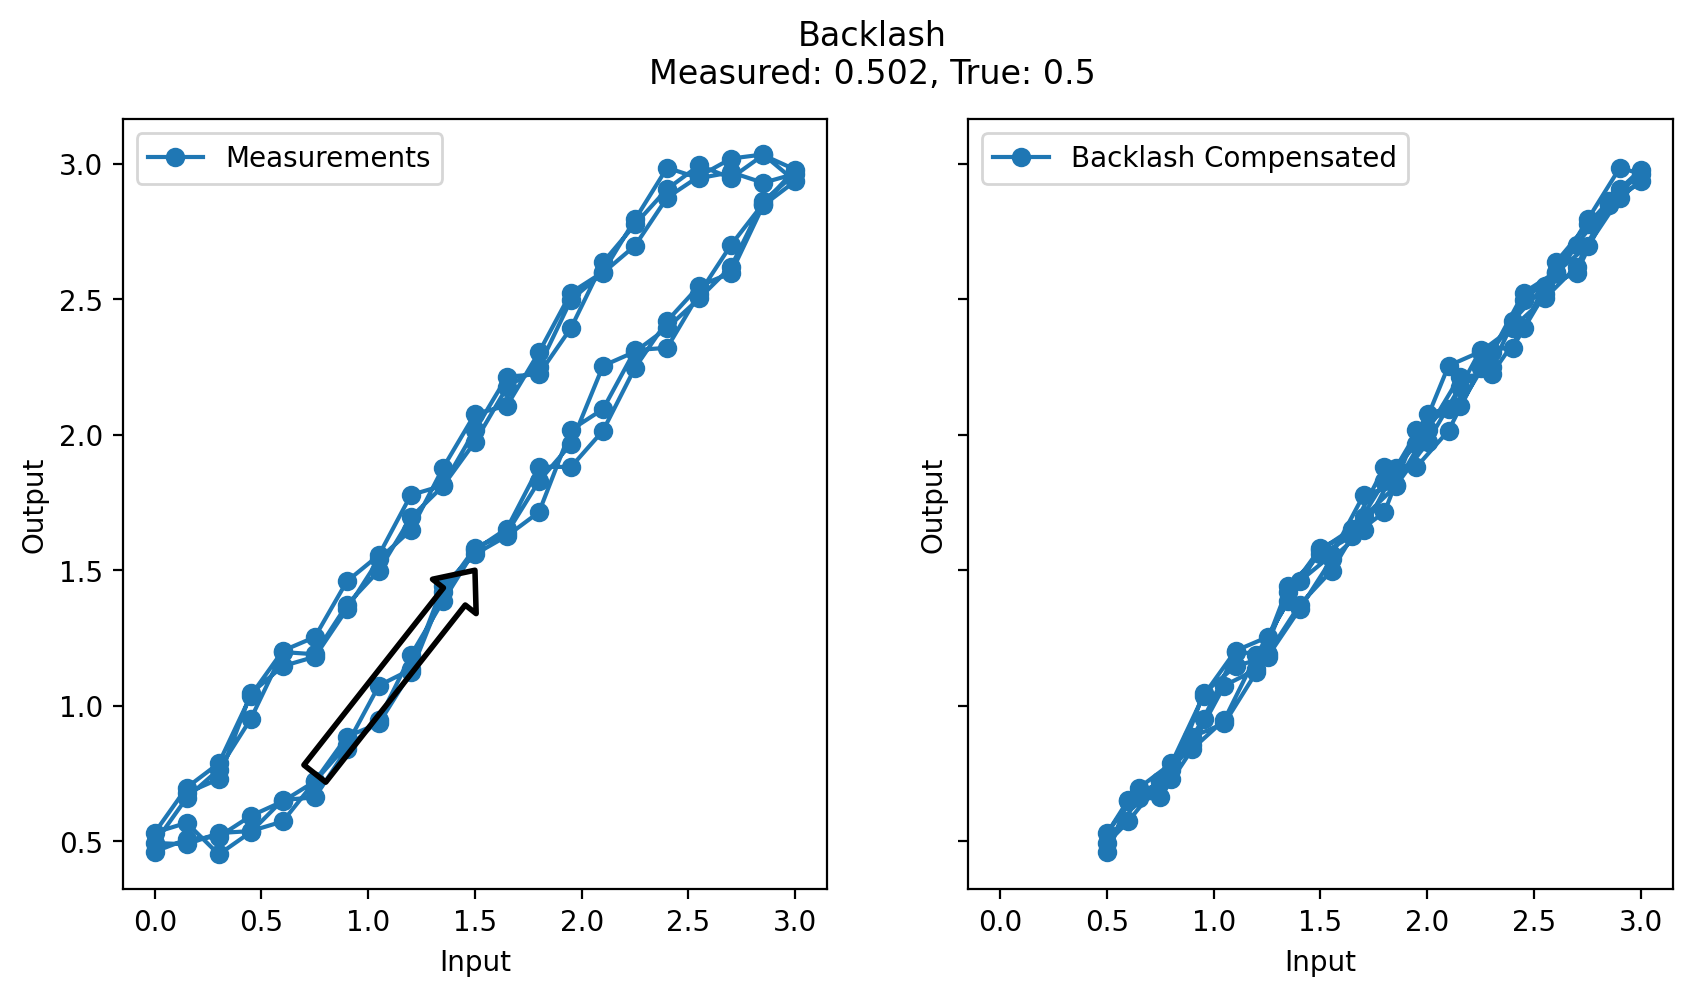

In [ ]:
true_backlash = 0.5
points_per_segment = 20
amplitude = 3 
num_cycles = 3

# generate noisy backlash loop data
input_loop = np.concatenate([np.arange(points_per_segment), np.arange(points_per_segment, 0, -1)])/points_per_segment*amplitude
output_loop = np.concatenate([
    (input_loop[:points_per_segment]).clip(min=true_backlash),
    (input_loop[points_per_segment:]+true_backlash).clip(max=amplitude)
])
inputs = np.tile(input_loop, num_cycles)
outputs = np.tile(output_loop, num_cycles) + np.random.normal(0, noise_dev, size=inputs.shape)

fig, (raw, comp) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)


raw.plot(inputs, outputs, marker='o', label="Measurements")
arrowprops = dict(facecolor="none", edgecolor="black", width=10, headwidth=20, linewidth=2)
raw.annotate("", xy=(amplitude/2, amplitude/2), xytext=(amplitude/4, amplitude/4), arrowprops=arrowprops)
raw.legend()
raw.set_xlabel("Input")
raw.set_ylabel("Output")

def backlash_integral(inputs, outputs, num_cycles):
    indices = np.arange(-1,len(inputs))
    integral = -np.trapezoid(outputs[indices], x=inputs[indices])
    # backlash == integral / cycles / output_amplitude == integral / cycles / (input_amplitude - backlash)
    # <=> backlash == input_amplitude / 2 - sqrt(input_amplitude**2 / 4 - integral / cycles)
    input_amplitude = np.ptp(inputs)
    return input_amplitude / 2 - np.sqrt(input_amplitude**2 / 4 - integral / num_cycles)

def remove_backlash(inputs, outputs, backlash):
    is_forward = np.diff(inputs, prepend=inputs[0]) > 0
    is_forward[0] = is_forward[-1]

    min_input = np.min(inputs)
    max_input = np.max(inputs)
    raw_comp_inputs = np.where(is_forward, inputs, inputs + backlash)
    # valid_indices = np.ones_like(inputs, dtype=bool)
    valid_indices = (raw_comp_inputs >= min_input + backlash) & is_forward | (raw_comp_inputs <= max_input) & ~is_forward

    return raw_comp_inputs[valid_indices], outputs[valid_indices]
    
backlash = backlash_integral(inputs, outputs, num_cycles)
comp_inputs, comp_outputs = remove_backlash(inputs, outputs, backlash)
comp.plot(comp_inputs, comp_outputs, marker='o', label="Backlash Compensated")
comp.set_xlabel("Input")
comp.set_ylabel("Output")
comp.legend()


fig.suptitle(f"Backlash\nMeasured: {backlash:.3f}, True: {true_backlash}")
fig.savefig("backlash.png", bbox_inches="tight")

## Backlash Variation

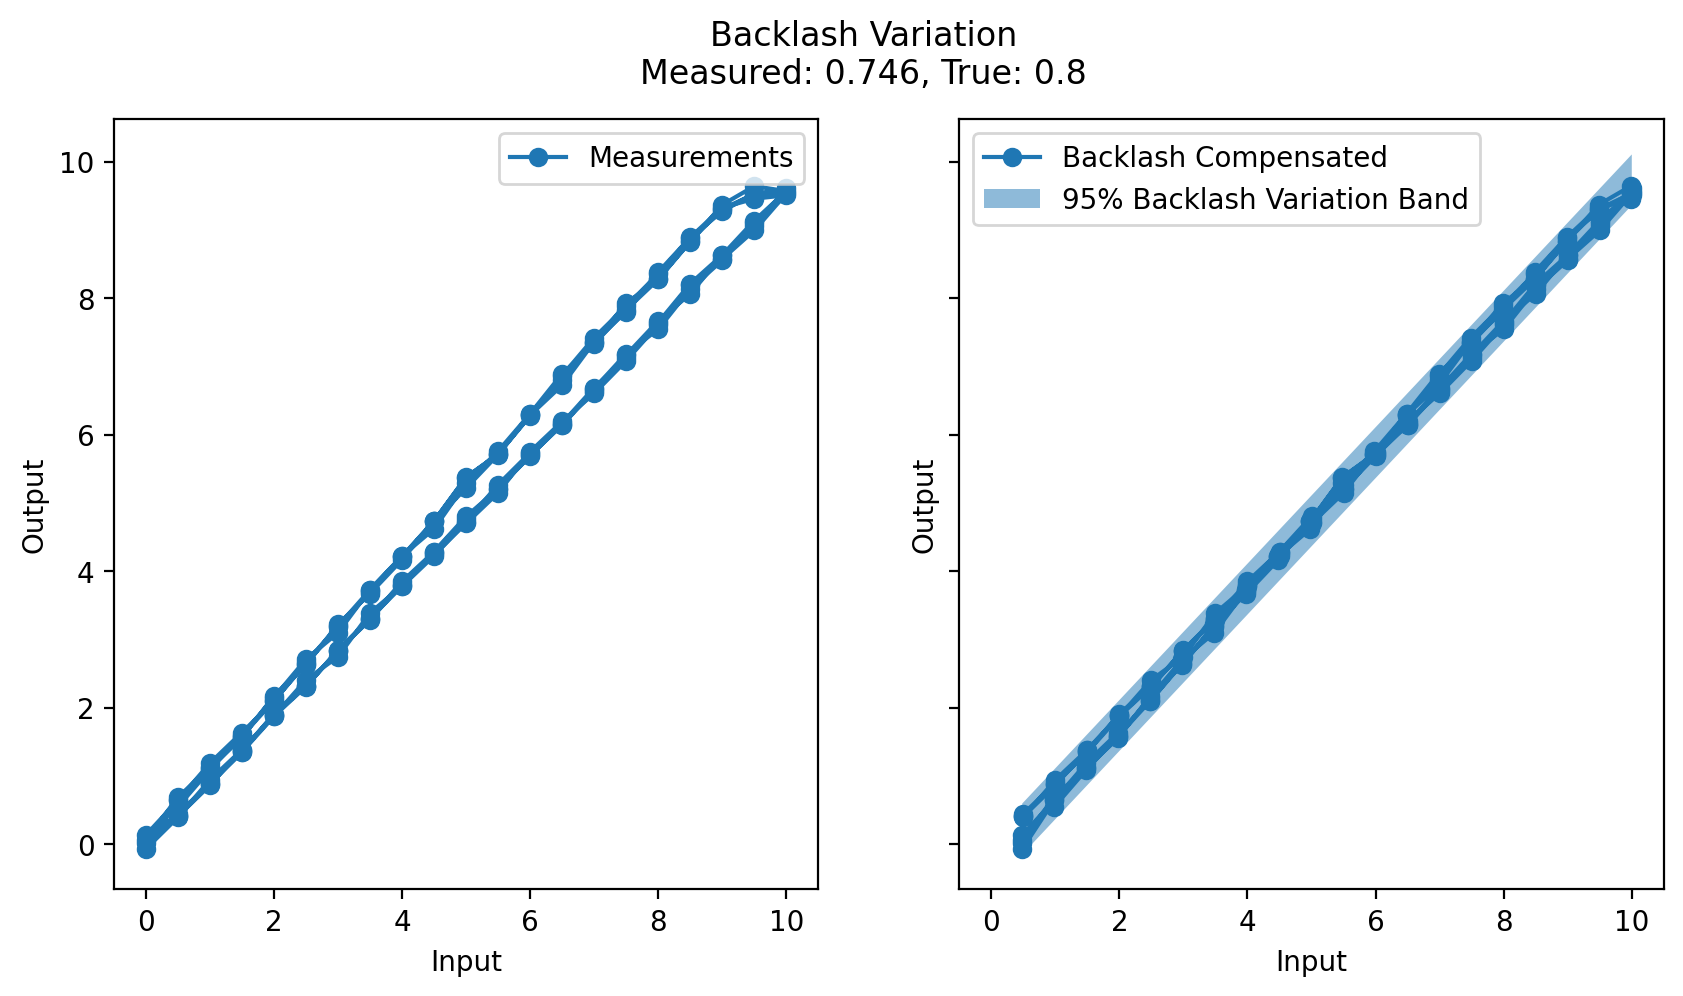

In [ ]:
def gaussian_kernel_interpolator(x, y, bandwidth):
    return np.vectorize(lambda x_new: np.sum(y*np.exp(-(x_new-x)**2/(2*bandwidth**2)))/np.sum(np.exp(-(x_new-x)**2/(2*bandwidth**2))))

true_backlash_mean = 0.5
true_backlash_variation = 0.8
points_per_segment = 20
amplitude = 10
num_cycles = 4

# generate data
backlash_func = lambda x: true_backlash_mean - true_backlash_variation/2 + true_backlash_variation/amplitude*x
input_loop = np.concatenate([np.arange(points_per_segment), np.arange(points_per_segment, 0, -1)])/points_per_segment*amplitude
output_loop = np.concatenate([
    (input_loop[:points_per_segment]-backlash_func(input_loop[:points_per_segment])/2).clip(min=backlash_func(0)/2),
    (input_loop[points_per_segment:]+backlash_func(input_loop[points_per_segment:])/2).clip(max=amplitude-backlash_func(amplitude)/2)
])
inputs = np.tile(input_loop, num_cycles)
outputs = np.tile(output_loop, num_cycles) + np.random.normal(0, noise_dev, size=inputs.shape)

fig, (raw, comp) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
raw.plot(inputs, outputs, marker='o', label="Measurements")
raw.legend()
raw.set_xlabel("Input")
raw.set_ylabel("Output")

# evaluate
is_forward = np.diff(inputs, prepend=inputs[0]) > 0
is_forward[0] = is_forward[-1]

bw = np.abs(np.diff(outputs)).mean()

forward_interpolator = gaussian_kernel_interpolator(inputs[is_forward], outputs[is_forward], bandwidth=bw)
backward_interpolator = gaussian_kernel_interpolator(inputs[~is_forward], outputs[~is_forward], bandwidth=bw)

residuals = np.where(is_forward, outputs - backward_interpolator(inputs), outputs - forward_interpolator(inputs))
lower, upper = np.quantile(residuals, [(1-interval)/2, 1-(1-interval)/2])
backlash_variation = (upper - lower)/2


backlash_mean = backlash_integral(inputs, outputs, num_cycles)

inputs_comp, outputs_comp = remove_backlash(inputs, outputs, backlash_mean)

comp.plot(inputs_comp, outputs_comp, marker='o', label="Backlash Compensated")
comp.set_xlabel("Input")
comp.set_ylabel("Output")

mean = np.polynomial.Polynomial([np.mean(outputs_comp-inputs_comp), 1])
input_range = np.array([np.min(inputs_comp), np.max(inputs_comp)])
comp.fill_between(input_range, mean(input_range) + backlash_variation/2, mean(input_range) - backlash_variation/2, alpha=0.5, label=f"{int(interval*100)}% Backlash Variation Band")
comp.legend()

fig.suptitle(f"Backlash Variation\nMeasured: {backlash_variation:.3f}, True: {true_backlash_variation}")
fig.savefig("backlash_variation.png", bbox_inches="tight")

## Nonlinearity

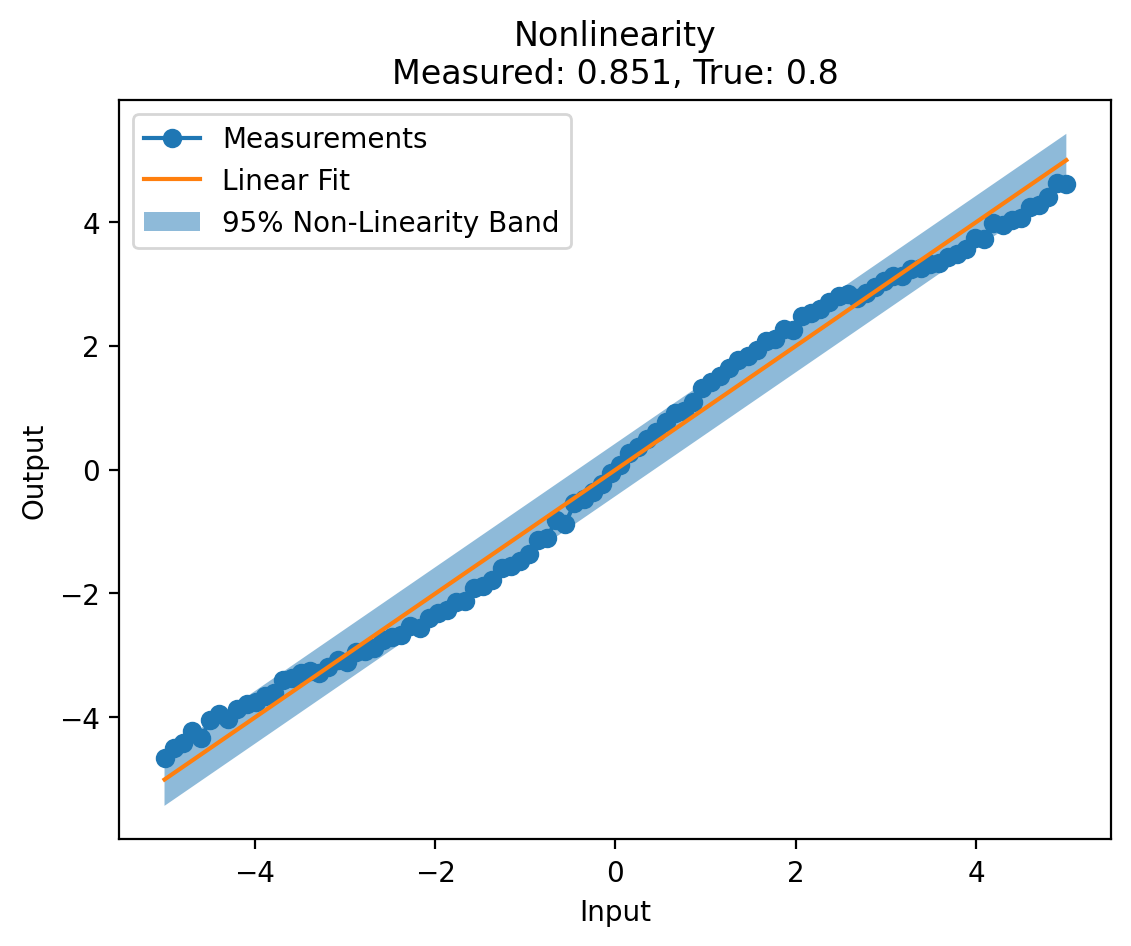

In [ ]:
true_non_linearity = 0.8

inputs = np.linspace(-5, 5, 100)
outputs = inputs + np.sin(inputs)*true_non_linearity/2 + np.random.normal(0, noise_dev, size=inputs.shape)

mean = np.polynomial.Polynomial([np.mean(outputs-inputs), 1])
residuals = outputs - mean(inputs)
lower, upper = np.quantile(residuals, [(1-interval)/2, 1-(1-interval)/2])
non_linearity = upper - lower

plt.plot(inputs, outputs, marker='o', label="Measurements")
plt.plot(inputs, mean(inputs), label="Linear Fit")
plt.fill_between(inputs, mean(inputs) + non_linearity/2, mean(inputs) - non_linearity/2, alpha=0.5, label=f"{int(interval*100)}% Nonlinearity Band")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title(f"Nonlinearity\nMeasured: {non_linearity:.3f}, True: {true_non_linearity}")
plt.legend()
plt.savefig("nonlinearity.png", bbox_inches="tight")